In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input
from tensorflow.keras.callbacks import EarlyStopping
import warnings
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D, MaxPooling1D,
    LSTM,
    Dense, Dropout, Flatten
)
from tensorflow.keras.utils import to_categorical


# (경고 메시지 무시 - 깨끗한 출력을 위해)
warnings.filterwarnings('ignore')

In [3]:
# --- 1-1. 트랜스포머 인코더 블록 ---
# (이 셀 안에서 새로 정의)
class TransformerEncoder(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super().__init__()
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential([
            layers.Dense(ff_dim, activation="relu"),
            layers.Dense(embed_dim),
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)

    # 💡💡💡 바로 이 부분입니다! training=None 💡💡💡
    # 이 셀에서 정의했으므로 100% 이 코드가 실행됩니다.
    def call(self, inputs, training=None):
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# --- 1. 데이터 로드 및 전처리 ---

# 데이터셋이 압축 해제된 경로 (본인 환경에 맞게 수정)
# 예: './data/UCI HAR Dataset/'
DATASET_PATH = '/content/drive/MyDrive/UCI HAR Dataset/'

# 원시 신호 데이터를 로드하는 함수
def load_signal_data(split): # split = 'train' 또는 'test'
    # 9개 축의 파일 리스트
    signal_files = [
        f'body_acc_x_{split}.txt', f'body_acc_y_{split}.txt', f'body_acc_z_{split}.txt',
        f'body_gyro_x_{split}.txt', f'body_gyro_y_{split}.txt', f'body_gyro_z_{split}.txt',
        f'total_acc_x_{split}.txt', f'total_acc_y_{split}.txt', f'total_acc_z_{split}.txt'
    ]

    # 데이터를 담을 리스트
    signal_data = []

    # 9개 파일을 순서대로 읽어서 리스트에 추가
    for file_name in signal_files:
        file_path = f'{DATASET_PATH}{split}/Inertial Signals/{file_name}'
        # 공백으로 구분된 텍스트 파일을 로드
        df = pd.read_csv(file_path, delim_whitespace=True, header=None)
        # NumPy 배열로 변환하여 리스트에 추가
        signal_data.append(df.values)

    # (9, 샘플 수, 128) 형태의 리스트를 (샘플 수, 128, 9) 형태로 변환
    # np.stack을 사용해 3번째 축(특징 축)으로 쌓음
    X_data = np.stack(signal_data, axis=-1)

    return X_data

# 라벨 데이터를 로드하는 함수
def load_label_data(split): # split = 'train' 또는 'test'
    file_path = f'{DATASET_PATH}{split}/y_{split}.txt'
    df = pd.read_csv(file_path, header=None)

    # 라벨이 1부터 6까지이므로 0부터 5까지로 조정 (원-핫 인코딩을 위해)
    y_data = df.values - 1

    # 원-핫 인코딩 수행
    return to_categorical(y_data, num_classes=6)

# 데이터 로드 실행
print("데이터 로딩 시작...")
X_train = load_signal_data('train')
X_test = load_signal_data('test')
y_train = load_label_data('train')
y_test = load_label_data('test')

데이터 로딩 시작...


In [6]:
# --- 1-2. 포지셔널 임베딩 레이어 ---
# (이 셀 안에서 새로 정의)
class PositionalEmbedding(layers.Layer):
    def __init__(self, maxlen, embed_dim):
        super().__init__()
        self.maxlen = maxlen
        self.pos_emb = layers.Embedding(input_dim=maxlen, output_dim=embed_dim)

    def call(self, x):
        positions = tf.range(start=0, limit=self.maxlen, delta=1)
        positions = self.pos_emb(positions)
        return x + positions

In [7]:
# --- 2. 트랜스포머 모델 구축 (Functional API) ---
print("\n--- 트랜스포머 모델 구축 (Functional API) ---")

# (데이터가 X_train, y_train 등에 이미 로드되었다고 가정)
# 만약 런타임 재시작으로 X_train이 사라졌다면 데이터 로드부터 다시 하셔야 합니다.
n_timesteps = X_train.shape[1] # 128
n_features = X_train.shape[2]  # 9
n_classes = y_train.shape[1]   # 6

embed_dim = 32
num_heads = 2
ff_dim = 32


--- 트랜스포머 모델 구축 (Functional API) ---


In [8]:
# 모델 구축
inputs = Input(shape=(n_timesteps, n_features))
x = layers.Dense(embed_dim, activation='relu')(inputs)
x = PositionalEmbedding(n_timesteps, embed_dim)(x)
# ⬇️ 이 줄이 실행될 때, 바로 위에서 정의한 'training=None' 버전의 클래스를 사용함
x = TransformerEncoder(embed_dim, num_heads, ff_dim, rate=0.2)(x)
x = layers.GlobalAveragePooling1D()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(32, activation="relu")(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(n_classes, activation="softmax")(x)

model = Model(inputs=inputs, outputs=outputs)

print("모델 구축 성공! `training` 에러가 해결되었습니다.")
model.summary()

모델 구축 성공! `training` 에러가 해결되었습니다.


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 9)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128, 32)        │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ positional_embedding            │ (None, 128, 32)        │         4,096 │
│ (PositionalEmbedding)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder             │ (None, 128, 32)        │        10,656 │
│ (TransformerEncoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,326 (63.77 KB)

 Trainable params: 16,326 (63.77 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# (이어서 3단계 - 컴파일 및 학습 코드도 이 셀에 붙여넣으셔도 됩니다)
# --- 3. 모델 컴파일 및 학습 ---
print("\n--- 모델 컴파일 및 학습 시작 ---")

optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
model.compile(loss='categorical_crossentropy',
              optimizer=optimizer,
              metrics=['accuracy'])

early_stopping = EarlyStopping(monitor='val_loss',
                              patience=10,
                              restore_best_weights=True)

history = model.fit(X_train, y_train,
                    epochs=50,
                    batch_size=64,
                    validation_data=(X_test, y_test),
                    callbacks=[early_stopping])


--- 모델 컴파일 및 학습 시작 ---
Epoch 1/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 19s 75ms/step - accuracy: 0.1670 - loss: 2.1248 - val_accuracy: 0.3610 - val_loss: 1.5901
Epoch 2/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.2608 - loss: 1.7985 - val_accuracy: 0.4007 - val_loss: 1.4218
Epoch 3/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3399 - loss: 1.5944 - val_accuracy: 0.4374 - val_loss: 1.3047
Epoch 4/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3771 - loss: 1.4828 - val_accuracy: 0.5066 - val_loss: 1.2038
Epoch 5/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4125 - loss: 1.3682 - val_accuracy: 0.5450 - val_loss: 1.1259
Epoch 6/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4641 - loss: 1.2828 - val_accuracy: 0.5860 - val_loss: 1.0491
Epoch 7/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4855 - loss: 1.2241 - val_accuracy: 0.6254 - val_loss: 0.9721
Epoch 8/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5142 - loss:

In [10]:
# --- 4. 모델 평가 ---
# (이전과 동일)
print("\n--- 모델 평가 ---")
loss, accuracy = model.evaluate(X_test, y_test)
print(f'테스트 데이터 손실(Loss): {loss:.4f}')
print(f'테스트 데이터 정확도(Accuracy): {accuracy * 100:.2f} %')


--- 모델 평가 ---
93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8378 - loss: 0.5208
테스트 데이터 손실(Loss): 0.4586
테스트 데이터 정확도(Accuracy): 86.77 %



--- 학습 커브 그리기 ---


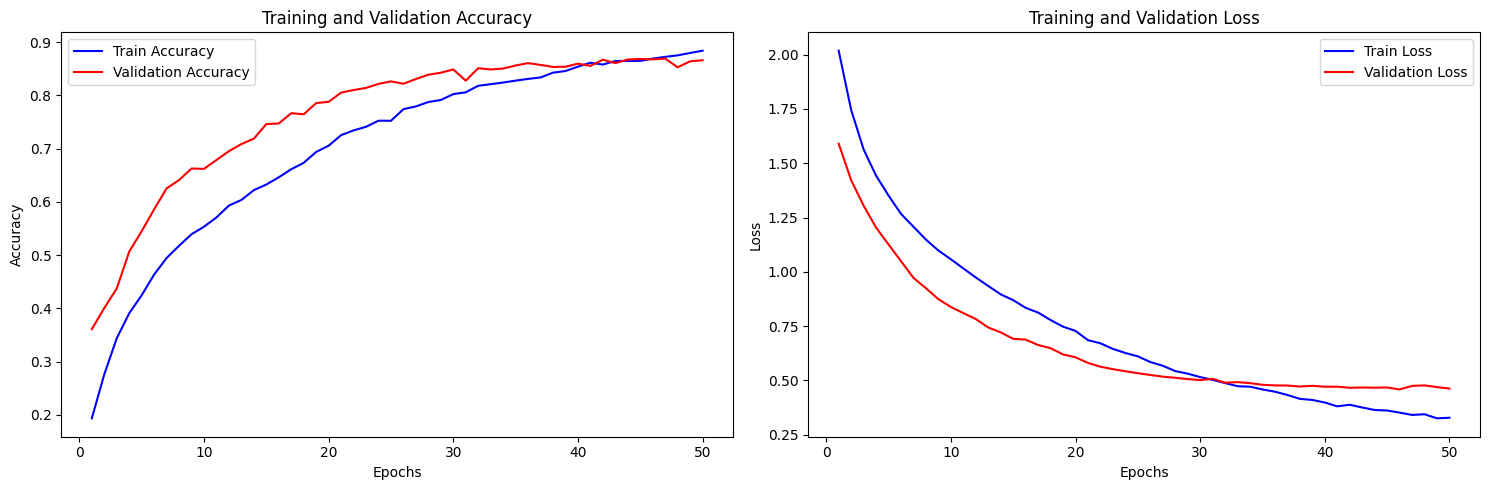

In [11]:
import matplotlib.pyplot as plt

# ----------------------------------------
# 1. 학습 커브 (정확도 및 손실)
# ----------------------------------------
print("\n--- 학습 커브 그리기 ---")

# history 객체에서 훈련 및 검증 정확도/손실 추출
history_dict = history.history
train_acc = history_dict['accuracy']
val_acc = history_dict['val_accuracy']
train_loss = history_dict['loss']
val_loss = history_dict['val_loss']

# 에포크 수
epochs = range(1, len(train_acc) + 1)

# 1x2 크기의 서브플롯 생성
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# 📈 첫 번째 플롯: 정확도 (Accuracy)
ax1.plot(epochs, train_acc, 'b-', label='Train Accuracy')
ax1.plot(epochs, val_acc, 'r-', label='Validation Accuracy')
ax1.set_title('Training and Validation Accuracy')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.legend()

# 📉 두 번째 플롯: 손실 (Loss)
ax2.plot(epochs, train_loss, 'b-', label='Train Loss')
ax2.plot(epochs, val_loss, 'r-', label='Validation Loss')
ax2.set_title('Training and Validation Loss')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()


--- 혼동 행렬 그리기 ---
93/93 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step


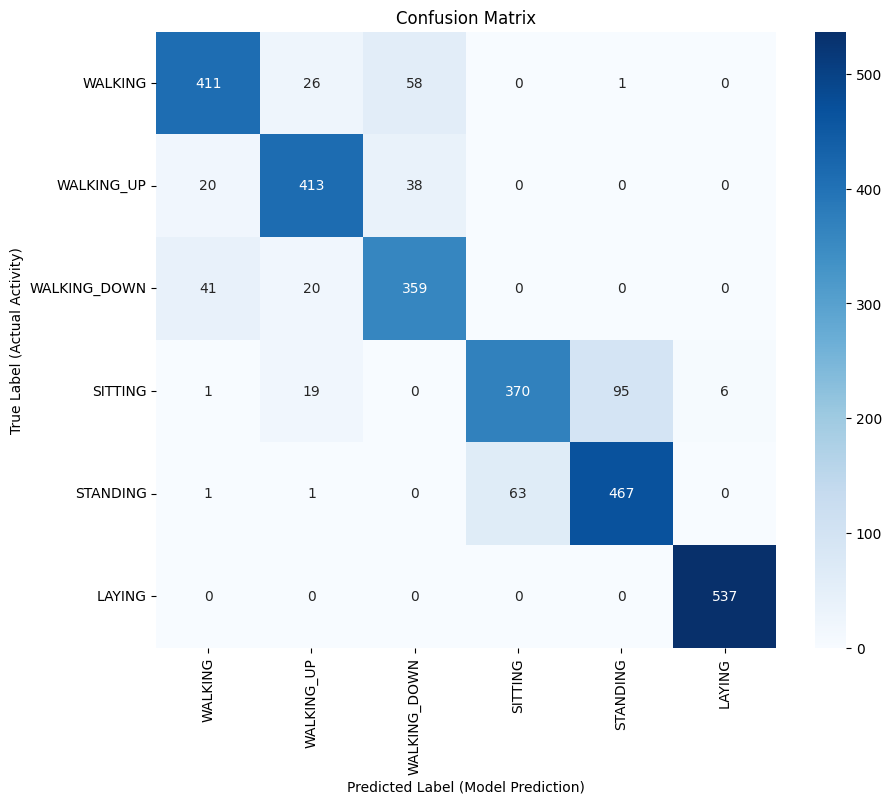

In [12]:
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

# ----------------------------------------
# 2. 혼동 행렬 (Confusion Matrix)
# ----------------------------------------
print("\n--- 혼동 행렬 그리기 ---")

# 테스트 데이터(X_test)로 예측 수행
y_pred_probs = model.predict(X_test)

# 확률을 클래스 인덱스로 변환
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# 실제 라벨(y_test)도 클래스 인덱스로 변환
y_true = np.argmax(y_test, axis=1)

# 혼동 행렬 계산
cm = confusion_matrix(y_true, y_pred_classes)

# 클래스(동작) 이름
class_names = [
    'WALKING', 'WALKING_UP', 'WALKING_DOWN',
    'SITTING', 'STANDING', 'LAYING'
]

# Seaborn으로 혼동 행렬 시각화
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)

plt.title('Confusion Matrix')
plt.ylabel('True Label (Actual Activity)')
plt.xlabel('Predicted Label (Model Prediction)')
plt.show()